# Imports

In [1]:
import pandas as pd
from main_search import *

In [2]:
### generate random input sequences for this test
reference_dataset = pd.DataFrame([{"SEQ_NAME": f"random_transcript_#{i:04d}", "SEQUENCE": random_seq(size = 1024)} for i in range(2048)])      # The references to check against, i.e. the transcriptome in this example
target            = pd.Series(    {"SEQ_NAME": "random_target",               "SEQUENCE": random_seq(size = 432)})                                        # The sequence from which we want ot find the best/unique binding site
# to be replaced by sequence data import


# Lets evaluate the affinities for each possible binding site sequence of target against a transcriptome
 - evaluate all target-sequence substrings = queries of specific length against a reference dataset


In [3]:

def target_site_search(
    reference_dataset:pd.DataFrame,
    target:pd.Series,
    query_len:int = 12,
    use_weights:bool = True,
    r2t:bool = True,
    save_path = None,
    ):
    '''
    - evaluate all target-sequence substrings = queries of specific length against a reference dataset
    - evaluate = calculate binding affinities of queries(all potential binding site of target) in the reference_dataset (usually transcriptome)
    IMPORTANT: reference_dataset and target require to have to following columns/attributes: SEQ_NAME, SEQUENCE
     - optional column/attibute WEIGHT (can contain e.g. concentrations) is required when setting use_weights = True
     - r2t = calculate affinities in transcriptome relative to affinity of target. i.e. Boltzmann factor of .5 means half as likely to bind compared to target
    '''

    
    # generate dataset of all possible binding sequences
    if use_weights:
        query_dataset = pd.DataFrame([{"POSITION": k, "SEQ_NAME": target.SEQ_NAME + f"_{k:03d}:{k+query_len:03d}", "SEQUENCE":target.SEQUENCE[k:k+query_len],  "WEIGHT": target.WEIGHT} for k in range(len(target.SEQUENCE)-query_len)] )
    else: 
        query_dataset = pd.DataFrame([{"POSITION": k, "SEQ_NAME": target.SEQ_NAME + f"_{k:03d}:{k+query_len:03d}", "SEQUENCE":target.SEQUENCE[k:k+query_len]} for k in range(len(target.SEQUENCE)-query_len)] )
        
    #-------------------------------#
    #  Parallel processing: joblib  #  
    #-------------------------------#          # using joblib instead of multiprocessing for windows compatibility and tqdm integration

    results = pd.DataFrame(list(tqdm(total=len(query_dataset), ncols = 100, 
            iterable=Parallel(return_as="generator", n_jobs=-1)(
                delayed(query_sc_summary)(query = query, reference_dataset = reference_dataset, target = target, use_weights = use_weights, r2t = r2t) for row_ID, query in query_dataset.iterrows())
            )))

    if save_path != None:
        import pathlib
        pathlib.Path(save_path).mkdir(parents=True, exist_ok=True) 
        results.to_csv(                          pathlib.Path(save_path).joinpath(f"random_results.csv"),    index = False)
        reference_dataset.to_csv(                pathlib.Path(save_path).joinpath(f"random_references.csv"), index = False)
        pd.DataFrame([target]).to_csv(           pathlib.Path(save_path).joinpath(f"random_target.csv"),     index = False)

    return results


In [4]:
DF = target_site_search(reference_dataset, target, use_weights = False, query_len = 12)

100%|█████████████████████████████████████████████████████████████| 420/420 [00:23<00:00, 18.03it/s]


# Visualize results and sort for most specific binding sites sequences
- thats a lot of results, lets try to understand what we got
- remember the goal: find the queries with the lowest chance of binding in the trancsriptome

identical match


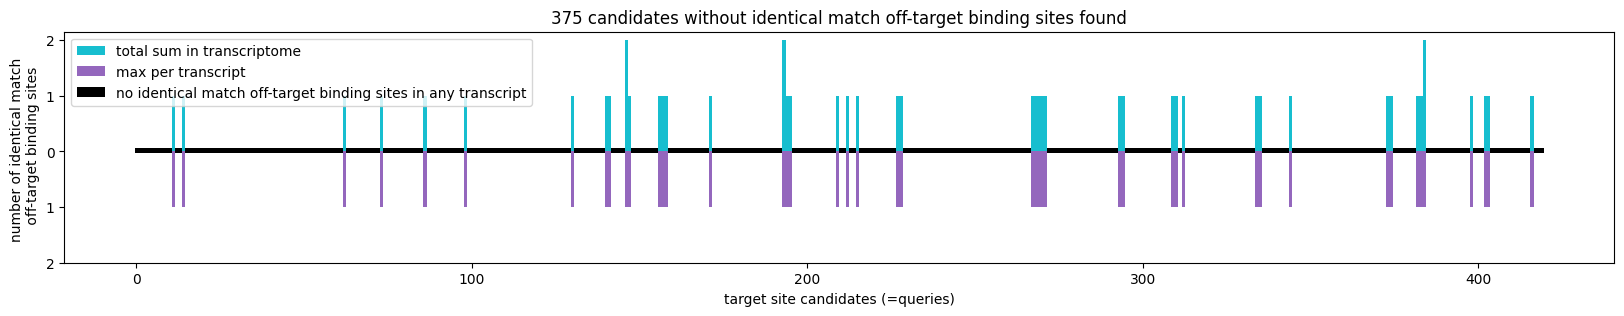

1nt mismatch


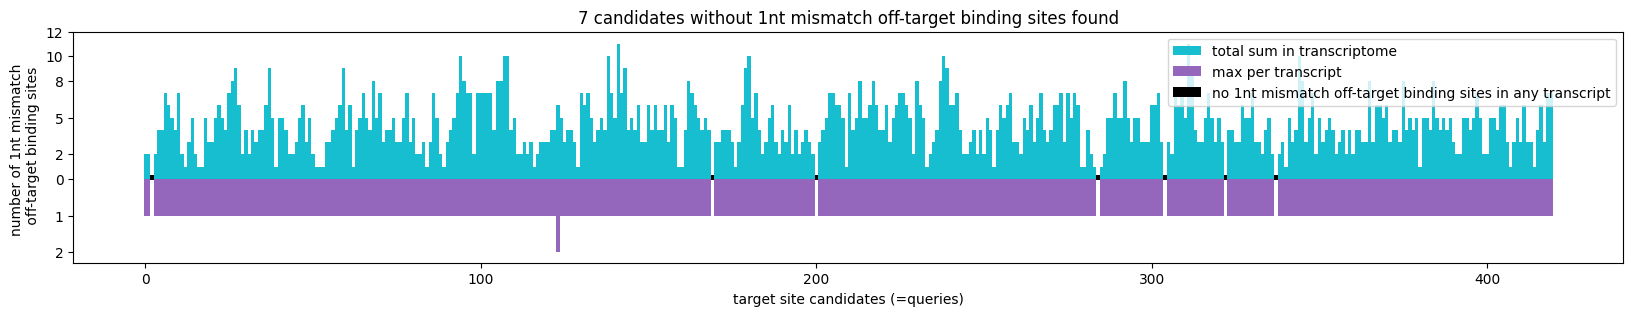

2nt mismatch


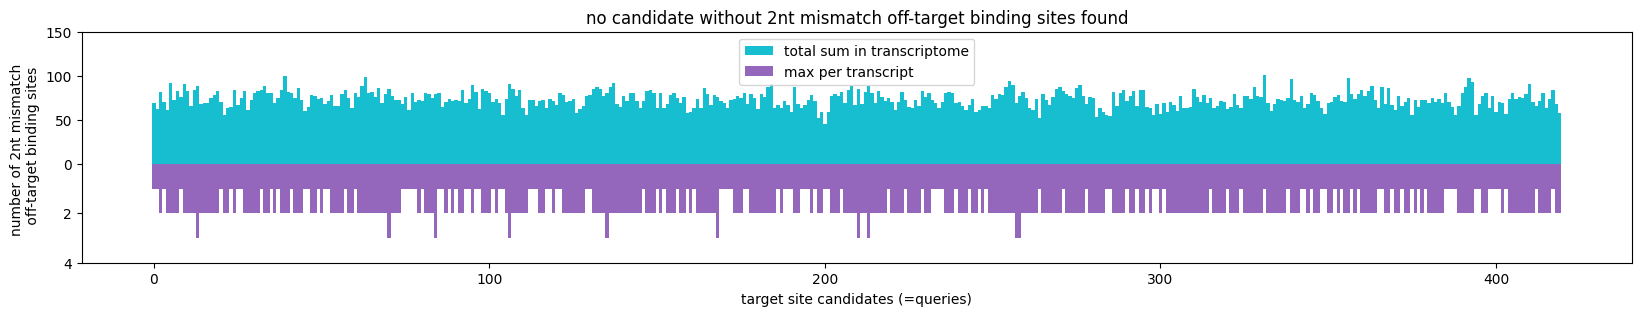

boltzmann factor


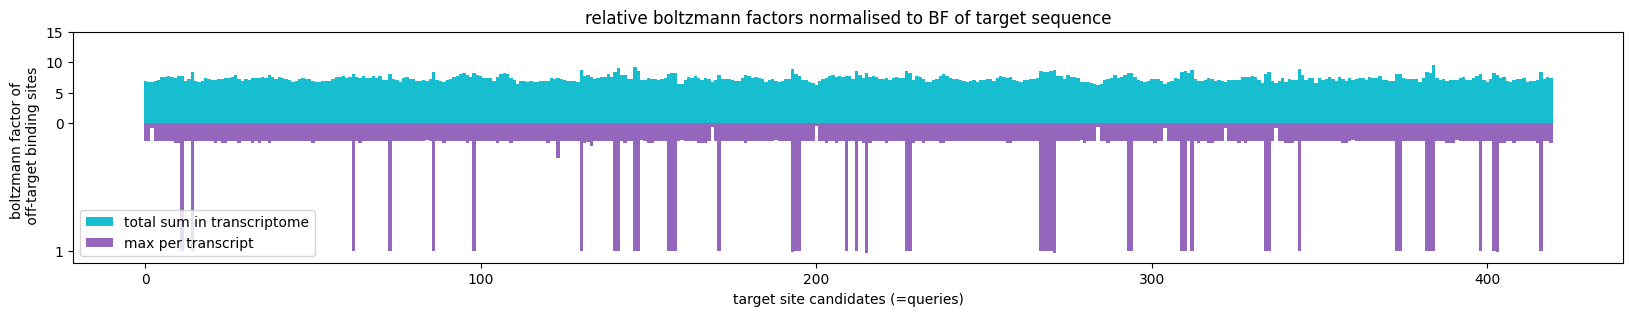

In [5]:
df_map(DF)  # Lets visualize the specificy of the queries (i.e. the potential binding sites of the target )

# selection


In [6]:
df_genRanks(DF)
df_select_against_outliers(DF, 16) # select 16 best
#df_PCA(DF)
df_table(DF) 

**table explanation**
 - first column is the position on the target
 - in the other columns red entries are worse than average, grey is average, blue (lower affinity to transcriptome) is better
 - columns starting with 'W.' used the WEIGHT column (e.g. expression level) provided to weight the contribution of each reference i.e. transcript on the overall result
 - each metric has max and sum result: sum is the sum over all references i.e. e.g. the affinity (boltzmann factor) of the whole transcriptome, while max is the worst affinity of a single transcript
 - Boltzmann factors can be understood as binding affinities. When column name is followed by 'r2t' then these results are relative affinities compared to target, i.e. an max affinity of 0.1 means it's 10x less likely to bind to the wordt reference, but a sum of 6 means its 6x more likely to bind to the transcriptome than to the target
 - rank is calculated based on all other columns.